# Modeling — RGB HOG + Logistic Regression

**Purpose:** We build the strict modeling manifest, run the tuned RGB HOG + Logistic Regression baseline, and inspect the selected classical model cleanly.

**Notebook Rules**
- We keep logic inside `src/`.
- We use a manual grid search over a fixed, explicit search space.
- We select the final classical baseline using **validation macro F1**.

In [1]:
# We set up the project path, import the shared config and utilities, and print the main project summary.

from pathlib import Path
import sys

currentDir = Path.cwd().resolve()
projectRoot = currentDir.parent if currentDir.name == "notebooks" else currentDir

if str(projectRoot) not in sys.path:
    sys.path.append(str(projectRoot))

from src.config import projectConfig
from src.utils import ensureProjectDirs, printProjectSummary, setGlobalSeed, applyPlotStyle

setGlobalSeed(projectConfig.seed)
ensureProjectDirs(projectConfig)
applyPlotStyle()
printProjectSummary(projectConfig)

projectRoot: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis
seed: 27
device: mps
imageDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/JPEGImages
annotationDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/Annotations
splitFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/train_val_test_split.txt
classFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/class_definitions.txt
cropsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataProcessed/crops
metricsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/metrics


### Strict Modeling Manifest

We first rebuild the strict modeling manifest so the classical baseline trains only on the leakage-aware crop list.

In [2]:
# We build the strict modeling manifest and collect the saved artifact paths.

import pandas as pd

from src.data import runModelingManifestBuilder

modelingResult = runModelingManifestBuilder(projectConfig)
modelingSummary = modelingResult["modelingSummary"]
modelingSavedPathDict = modelingResult["savedPathDict"]

modelingSummaryDf = pd.DataFrame(
    {
        "metricName": list(modelingSummary.keys()),
        "metricValue": list(modelingSummary.values()),
    }
)

modelingSummaryDf

,metricName,metricValue
0,rawCropCount,1584
1,strictModelingCropCount,1580
2,excludedDuplicateCropCount,4
3,excludedCrossSplitDuplicateCropCount,2
4,strictUniqueSourceImageCount,1061
5,strictTrainCropCount,1097
6,strictValCropCount,245
7,strictTestCropCount,238


### RGB HOG + Logistic Regression Tuning Plan

We now run a focused **30-trial** manual grid search for the classical Logistic Regression baseline.

We keep the search centered around the already strong HOG region and test:
- three image sizes
- five Logistic Regression `C` values
- two HOG orientation settings
- RGB HOG only

This gives a strong but still controlled classical baseline search.

In [3]:
# We define a structured 100-trial RGB-only HOG + Logistic Regression search space with stronger regularization.

hogLogisticRegressionSearchSpace = {
    "imageSizeList": [112, 128, 144, 160],
    "cValueList": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3],
    "pixelsPerCellList": [(8, 8), (16, 16)],
    "orientationsList": [9, 12],
    "colorModeList": ["rgb"],
}

hogLogisticRegressionSearchSpace

{'imageSizeList': [112, 128, 144, 160],
 'cValueList': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3],
 'pixelsPerCellList': [(8, 8), (16, 16)],
 'orientationsList': [9, 12],
 'colorModeList': ['rgb']}

### Train the Tuned Classical Baseline

This cell runs the complete classical baseline search and saves the selected best artifacts. The later inspection cells read the saved outputs from disk.

In [4]:
# We run the tuned RGB HOG + Logistic Regression baseline and keep the saved artifact paths.

from src.models.logisticRegressionModel import runTunedHogLogisticRegressionBaseline

baselineResult = runTunedHogLogisticRegressionBaseline(
    projectConfig=projectConfig,
    searchSpace=hogLogisticRegressionSearchSpace,
    logisticTol=1e-3,
    logisticMaxIter=2000,
    verbose=True,
)

baselineSavedPathDict = baselineResult["savedPathDict"]

print("Tuned RGB HOG + Logistic Regression baseline completed.")
print("Saved files:")
for tableName, outputPath in baselineSavedPathDict.items():
    print(f"{tableName}: {outputPath}")

[HOG cache] Setting 1/16 | imageSize=112 | pixelsPerCell=(8, 8) | orientations=9 | colorMode=rgb
[HOG cache] Setting 2/16 | imageSize=112 | pixelsPerCell=(8, 8) | orientations=12 | colorMode=rgb
[HOG cache] Setting 3/16 | imageSize=112 | pixelsPerCell=(16, 16) | orientations=9 | colorMode=rgb
[HOG cache] Setting 4/16 | imageSize=112 | pixelsPerCell=(16, 16) | orientations=12 | colorMode=rgb
[HOG cache] Setting 5/16 | imageSize=128 | pixelsPerCell=(8, 8) | orientations=9 | colorMode=rgb
[HOG cache] Setting 6/16 | imageSize=128 | pixelsPerCell=(8, 8) | orientations=12 | colorMode=rgb
[HOG cache] Setting 7/16 | imageSize=128 | pixelsPerCell=(16, 16) | orientations=9 | colorMode=rgb
[HOG cache] Setting 8/16 | imageSize=128 | pixelsPerCell=(16, 16) | orientations=12 | colorMode=rgb
[HOG cache] Setting 9/16 | imageSize=144 | pixelsPerCell=(8, 8) | orientations=9 | colorMode=rgb
[HOG cache] Setting 10/16 | imageSize=144 | pixelsPerCell=(8, 8) | orientations=12 | colorMode=rgb
[HOG cache] Sett

### Selected Baseline Configuration

We load the saved configuration and inspect the selected best HOG + Logistic Regression setting.

In [5]:
# We read the saved best-configuration JSON and convert the selected settings into a compact table.

import json

with open(baselineSavedPathDict["configPath"], "r", encoding="utf-8") as jsonFile:
    baselineConfig = json.load(jsonFile)

bestConfig = baselineConfig["bestConfig"]
bestValMetrics = baselineConfig["bestValMetrics"]
bestTrialMeta = baselineConfig["bestTrialMeta"]

bestConfigSummaryDf = pd.DataFrame(
    {
        "settingName": [
            "imageSize",
            "cValue",
            "pixelsPerCell",
            "orientations",
            "colorMode",
            "valMacroF1",
            "valMacroRecall",
            "valWeightedF1",
            "valAccuracy",
            "hadConvergenceWarning",
            "rankBySelection",
        ],
        "settingValue": [
            bestConfig["imageSize"],
            bestConfig["cValue"],
            tuple(bestConfig["pixelsPerCell"]),
            bestConfig["orientations"],
            bestConfig["colorMode"],
            bestValMetrics["macroF1"],
            bestValMetrics["macroRecall"],
            bestValMetrics["weightedF1"],
            bestValMetrics["accuracy"],
            bestTrialMeta["hadConvergenceWarning"],
            bestTrialMeta["rankBySelection"],
        ],
    }
)

bestConfigSummaryDf

,settingName,settingValue
0,imageSize,144
1,cValue,0.1
2,pixelsPerCell,"(16, 16)"
3,orientations,9
4,colorMode,rgb
5,valMacroF1,0.718424
6,valMacroRecall,0.733734
7,valWeightedF1,0.758896
8,valAccuracy,0.755102
9,hadConvergenceWarning,0


### Strongest Baseline Trials

We inspect the strongest tuning trials so we can see whether the selected winner is clearly best or whether several nearby configurations perform similarly.

In [6]:
# We read the saved tuning summary and inspect the strongest RGB HOG + Logistic Regression trials.

tuningSummaryDf = pd.read_csv(baselineSavedPathDict["tuningSummaryPath"])
tuningSummaryDf.head(10)

,trialNumber,featureCacheKey,imageSize,pixelsPerCellX,pixelsPerCellY,pixelsPerCellLabel,orientations,colorMode,cValue,logisticTol,...,trainMacroRecall,trainMacroF1,trainWeightedF1,valAccuracy,valMacroPrecision,valMacroRecall,valMacroF1,valWeightedF1,isSelectionEligible,rankBySelection
0,65,size144__ppc16x16__ori9__colorrgb,144,16,16,16x16,9,rgb,0.10,0.001,...,0.996624,0.996408,0.995446,0.755102,0.711627,0.733734,0.718424,0.758896,1,1
1,72,size144__ppc16x16__ori12__colorrgb,144,16,16,16x16,12,rgb,0.30,0.001,...,0.999400,0.999370,0.999089,0.746939,0.705790,0.740942,0.715562,0.752031,1,2
2,40,size128__ppc16x16__ori9__colorrgb,128,16,16,16x16,9,rgb,0.03,0.001,...,0.974718,0.974573,0.969181,0.730612,0.694831,0.730351,0.704400,0.736900,1,3
3,28,size128__ppc8x8__ori9__colorrgb,128,8,8,8x8,9,rgb,0.03,0.001,...,0.999400,0.999370,0.999089,0.730612,0.704847,0.707237,0.703370,0.733318,1,4
4,71,size144__ppc16x16__ori12__colorrgb,144,16,16,16x16,12,rgb,0.10,0.001,...,0.997823,0.997794,0.997267,0.730612,0.691611,0.715865,0.698148,0.734245,1,5
5,64,size144__ppc16x16__ori9__colorrgb,144,16,16,16x16,9,rgb,0.03,0.001,...,0.983161,0.982696,0.979135,0.730612,0.689067,0.715953,0.697797,0.734415,1,6
6,70,size144__ppc16x16__ori12__colorrgb,144,16,16,16x16,12,rgb,0.03,0.001,...,0.988791,0.988283,0.985461,0.730612,0.688351,0.718260,0.696563,0.735097,1,7
7,30,size128__ppc8x8__ori9__colorrgb,128,8,8,8x8,9,rgb,0.30,0.001,...,1.000000,1.000000,1.000000,0.706122,0.692487,0.700078,0.692147,0.709673,1,8
8,53,size144__ppc8x8__ori9__colorrgb,144,8,8,8x8,9,rgb,0.10,0.001,...,1.000000,1.000000,1.000000,0.726531,0.681016,0.708693,0.691509,0.730244,1,9
9,52,size144__ppc8x8__ori9__colorrgb,144,8,8,8x8,9,rgb,0.03,0.001,...,1.000000,1.000000,1.000000,0.730612,0.682590,0.702324,0.689673,0.733334,1,10


### Final Metric Summary

We inspect the selected tuned Logistic Regression baseline on train, validation, and test.

In [7]:
# We read the saved metric summary and inspect the final train, validation, and test comparison table.

metricSummaryDf = pd.read_csv(baselineSavedPathDict["metricSummaryPath"])
metricSummaryDf

,metricName,trainValue,valValue,testValue
0,accuracy,0.995442,0.755102,0.743697
1,macroPrecision,0.996210,0.711627,0.750084
2,macroRecall,0.996624,0.733734,0.750218
3,macroF1,0.996408,0.718424,0.749612
4,weightedF1,0.995446,0.758896,0.743101


### Validation Confusion Matrix

We inspect the validation confusion matrix of the selected tuned Logistic Regression baseline to understand the class-level error pattern that determined model selection.

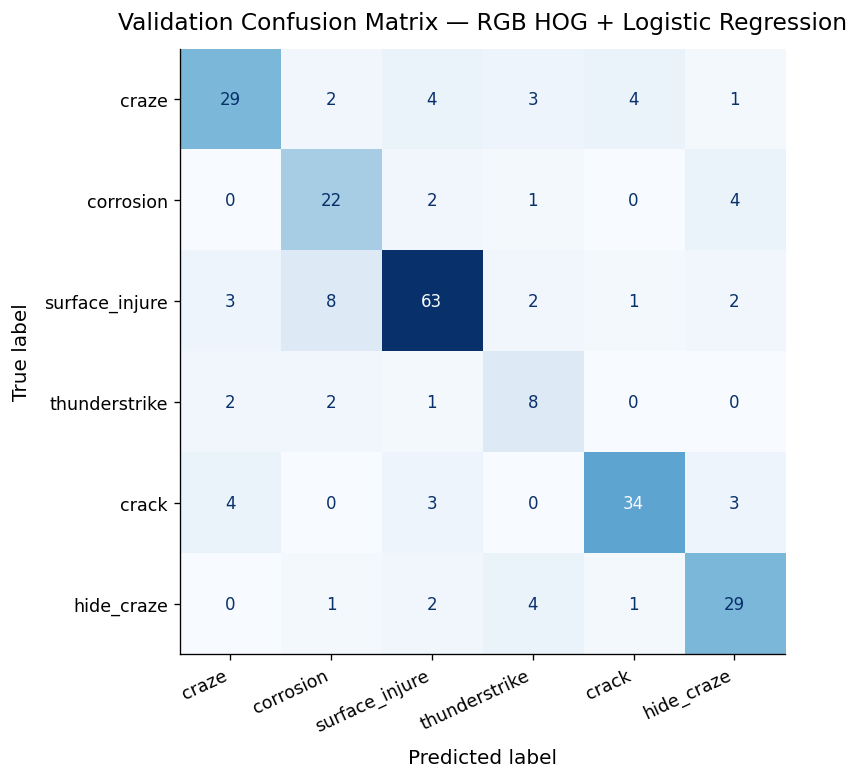

In [8]:
# We read the saved validation predictions and display the validation confusion matrix.

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

valPredictionDf = pd.read_csv(baselineSavedPathDict["valPredictionPath"])

valConfusionMatrix = confusion_matrix(
    valPredictionDf["className"],
    valPredictionDf["predictedClassName"],
    labels=projectConfig.classNames,
)

fig, ax = plt.subplots(figsize=(8.2, 6.6))

displayObject = ConfusionMatrixDisplay(
    confusion_matrix=valConfusionMatrix,
    display_labels=projectConfig.classNames,
)

displayObject.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",
)

ax.set_title("Validation Confusion Matrix — RGB HOG + Logistic Regression", pad=12)
ax.grid(False)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Test Confusion Matrix

We inspect the final test confusion matrix of the selected tuned Logistic Regression baseline after model selection is already complete.

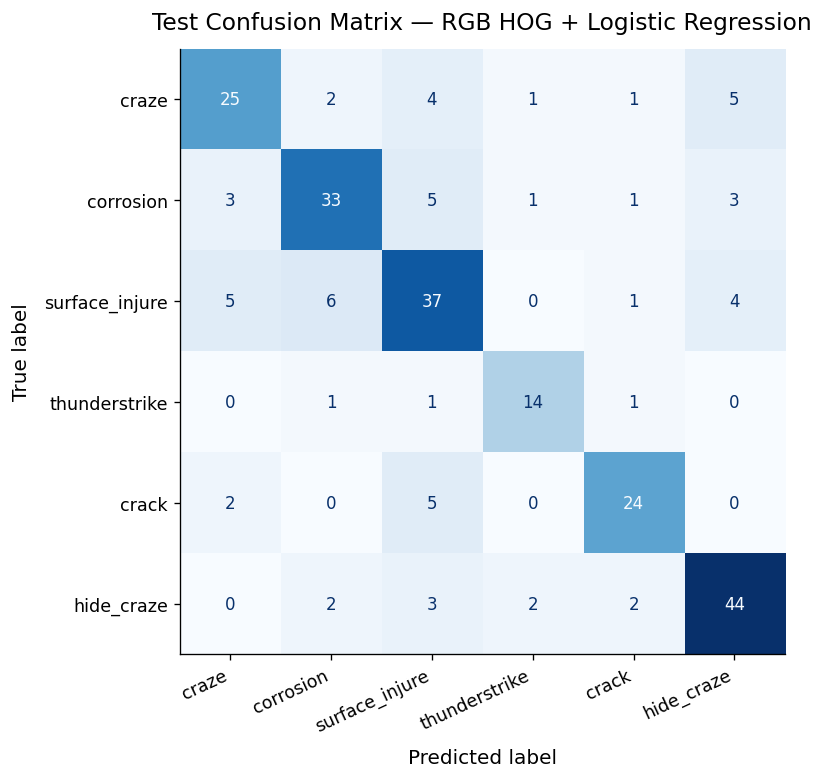

In [9]:
# We read the saved test predictions and display the final test confusion matrix.

testPredictionDf = pd.read_csv(baselineSavedPathDict["testPredictionPath"])

testConfusionMatrix = confusion_matrix(
    testPredictionDf["className"],
    testPredictionDf["predictedClassName"],
    labels=projectConfig.classNames,
)

fig, ax = plt.subplots(figsize=(8.2, 6.6))

displayObject = ConfusionMatrixDisplay(
    confusion_matrix=testConfusionMatrix,
    display_labels=projectConfig.classNames,
)

displayObject.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",
)

ax.set_title("Test Confusion Matrix — RGB HOG + Logistic Regression", pad=12)
ax.grid(False)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

The tuned RGB HOG + Logistic Regression baseline gives us a second classical benchmark on the same leakage-aware crop dataset.

We selected the final configuration using validation macro F1, so the chosen model reflects balanced multiclass performance rather than only overall accuracy. The tuning summary shows whether strong performance is isolated to one setting or supported by several nearby configurations. The final metric table and confusion matrices then show how the selected classical baseline behaves across train, validation, and test.

This Logistic Regression baseline is useful because it tells us whether the strong HOG representation mainly benefits from the exact linear classifier choice or whether the representation itself is already doing most of the work.

### Logistic Regression Macro F1 vs Regularization Strength

We inspect how macro F1 changes across the tested `C` values for the selected RGB HOG feature setting.  
To keep both the near-perfect training scores and the lower validation/test scores readable, we use a broken y-axis.

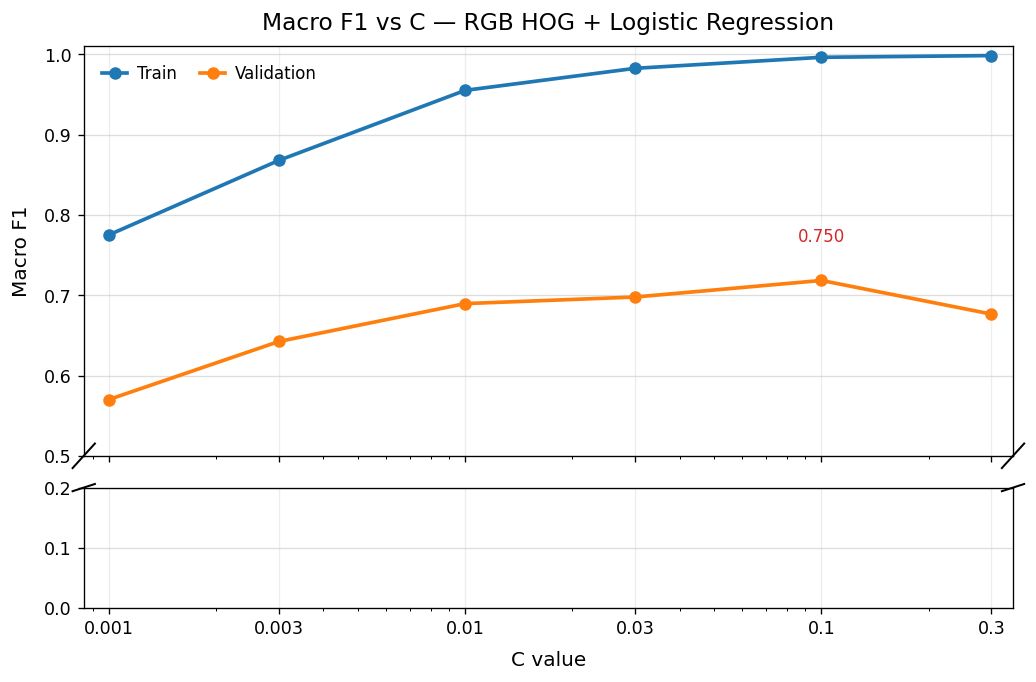

In [10]:
# We plot train and validation macro F1 across C values for the selected Logistic Regression feature setting.
# We only compute and show the test macro F1 value at the best validation C, while keeping the same broken y-axis style.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

from src.models.logisticRegressionModel import buildHogParamDict, buildSubsetFeatures

selectedImageSize = int(bestConfig["imageSize"])
selectedPixelsPerCell = (
    int(bestConfig["pixelsPerCell"][0]),
    int(bestConfig["pixelsPerCell"][1]),
)
selectedOrientations = int(bestConfig["orientations"])
selectedColorMode = str(bestConfig["colorMode"])

tuningSummaryDf = pd.read_csv(baselineSavedPathDict["tuningSummaryPath"])

selectedTrialRowsDf = tuningSummaryDf.loc[
    (
        (tuningSummaryDf["imageSize"] == selectedImageSize)
        & (tuningSummaryDf["pixelsPerCellX"] == selectedPixelsPerCell[0])
        & (tuningSummaryDf["pixelsPerCellY"] == selectedPixelsPerCell[1])
        & (tuningSummaryDf["orientations"] == selectedOrientations)
        & (tuningSummaryDf["colorMode"] == selectedColorMode)
    )
].copy()

selectedTrialRowsDf = selectedTrialRowsDf.sort_values("cValue").reset_index(drop=True)
cValueList = selectedTrialRowsDf["cValue"].astype(float).tolist()

bestValPosition = int(selectedTrialRowsDf["valMacroF1"].astype(float).to_numpy().argmax())
bestValCValue = float(selectedTrialRowsDf.loc[bestValPosition, "cValue"])

strictManifestPath = projectConfig.manifestsDir / "modelingManifestStrict.csv"
strictManifestDf = pd.read_csv(strictManifestPath)

classToIndexMap = {
    className: classIndex
    for classIndex, className in enumerate(projectConfig.classNames)
}
indexToClassMap = {
    classIndex: className
    for classIndex, className in enumerate(projectConfig.classNames)
}

selectedHogParams = buildHogParamDict(
    orientations=selectedOrientations,
    pixelsPerCell=selectedPixelsPerCell,
)

trainFeatures, trainTargets, trainDf = buildSubsetFeatures(
    modelingManifestDf=strictManifestDf,
    subsetName="train",
    classToIndexMap=classToIndexMap,
    imageSize=selectedImageSize,
    hogParams=selectedHogParams,
    colorMode=selectedColorMode,
)

testFeatures, testTargets, testDf = buildSubsetFeatures(
    modelingManifestDf=strictManifestDf,
    subsetName="test",
    classToIndexMap=classToIndexMap,
    imageSize=selectedImageSize,
    hogParams=selectedHogParams,
    colorMode=selectedColorMode,
)

bestValModelPipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                C=bestValCValue,
                class_weight="balanced",
                solver="lbfgs",
                random_state=projectConfig.seed,
                max_iter=5000,
                tol=1e-3,
            ),
        ),
    ]
)

bestValModelPipeline.fit(trainFeatures, trainTargets)
testPredictedIndices = bestValModelPipeline.predict(testFeatures)

testPredictedClassNames = [
    indexToClassMap[int(classIndex)]
    for classIndex in testPredictedIndices.tolist()
]

bestValTestMacroF1Value = float(
    f1_score(
        testDf["className"],
        testPredictedClassNames,
        average="macro",
        zero_division=0,
    )
)

plotDf = pd.DataFrame(
    {
        "cValue": cValueList,
        "trainMacroF1": selectedTrialRowsDf["trainMacroF1"].astype(float).tolist(),
        "valMacroF1": selectedTrialRowsDf["valMacroF1"].astype(float).tolist(),
    }
).sort_values("cValue").reset_index(drop=True)

xValues = plotDf["cValue"].astype(float).to_numpy()
trainValues = plotDf["trainMacroF1"].astype(float).to_numpy()
valValues = plotDf["valMacroF1"].astype(float).to_numpy()

blueColor = "#1f77b4"
orangeColor = "#ff7f0e"
redColor = "#d62728"
gridColor = "#d0d0d0"

fig, (axTop, axBottom) = plt.subplots(
    2,
    1,
    figsize=(8.8, 6.0),
    sharex=True,
    gridspec_kw={"height_ratios": [3.4, 1.0], "hspace": 0.12},
)

for axisObject in [axTop, axBottom]:
    axisObject.plot(xValues, trainValues, marker="o", linewidth=2.2, markersize=6.5, color=blueColor, label="Train")
    axisObject.plot(xValues, valValues, marker="o", linewidth=2.2, markersize=6.5, color=orangeColor, label="Validation")

    axisObject.grid(axis="y", color=gridColor, linewidth=0.8, alpha=0.7)
    axisObject.spines["top"].set_visible(True)
    axisObject.spines["right"].set_visible(True)
    axisObject.spines["left"].set_visible(True)
    axisObject.spines["bottom"].set_visible(True)

# Requested y ranges
axTop.set_ylim(0.50, 1.01)
axBottom.set_ylim(0.00, 0.20)

# X axis
axBottom.set_xscale("log")
axBottom.set_xlim(xValues.min() * 0.85, xValues.max() * 1.15)
axBottom.set_xticks(xValues)
axBottom.set_xticklabels([f"{currentValue:g}" for currentValue in xValues])

# Tick density
axTop.set_yticks(np.arange(0.5, 1.01, 0.1))
axBottom.set_yticks([0.0, 0.1, 0.2])

# Only show x tick labels on lower panel
axTop.tick_params(axis="x", which="both", labelbottom=False)

# Break marks on panel edges only
breakKwargs = dict(color="black", clip_on=False, linewidth=1.2)
axTop.plot((-0.012, +0.012), (-0.03, +0.03), transform=axTop.transAxes, **breakKwargs)
axTop.plot((0.988, 1.012), (-0.03, +0.03), transform=axTop.transAxes, **breakKwargs)
axBottom.plot((-0.012, +0.012), (0.97, 1.03), transform=axBottom.transAxes, **breakKwargs)
axBottom.plot((0.988, 1.012), (0.97, 1.03), transform=axBottom.transAxes, **breakKwargs)

# Legend
axTop.legend(
    loc="upper left",
    frameon=False,
    ncol=3,
    handlelength=1.5,
    columnspacing=1.4,
)

# Only the test value at the best validation C
axTop.text(
    bestValCValue,
    bestValTestMacroF1Value + 0.012,
    f"{bestValTestMacroF1Value:.3f}",
    ha="center",
    va="bottom",
    fontsize=10,
    color=redColor,
)

axTop.set_title("Macro F1 vs C — RGB HOG + Logistic Regression", pad=10)
axTop.set_ylabel("Macro F1")
axBottom.set_xlabel("C value")

fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.12)
plt.show()

In [11]:
# We save the approved Logistic Regression macro-F1-versus-C figure.

from src.utils import saveFigure

logisticMacroF1CurvePath = saveFigure(
    fig=fig,
    outputDir=projectConfig.figuresDir / "logisticRegression",
    figureFileName="logistic_macro_f1_vs_c_broken_axis_train_val_only.png",
    closeFigure=False,
)

print("Saved figure:", logisticMacroF1CurvePath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/logisticRegression/logistic_macro_f1_vs_c_broken_axis_train_val_only.png


**Interpretation**

This plot shows how macro F1 changes across the tested `C` values for the selected RGB HOG feature setting in Logistic Regression.

The upper panel focuses on the high training scores, while the lower panel preserves the full scale from 0 to 0.2 so that the broken axis remains explicit and visually honest. The training curve rises steadily as `C` increases, which means weaker regularization allows the model to fit the training set more strongly. The validation and test curves also improve at first, showing that some reduction in regularization is beneficial, but they do not improve indefinitely.

The most important curve for model selection is the validation curve. Here, validation macro F1 reaches its best region around `C = 0.1`. The test curve follows a very similar shape and also peaks in the same region, which supports that this configuration is not just a validation-specific accident. At the same time, the growing gap between the training curve and the validation/test curves shows that stronger fitting does not automatically translate into better generalization.

Overall, this figure supports the final choice of the tuned RGB HOG + Logistic Regression baseline and shows that the selected model lies in a reasonable regularization region rather than at an unstable extreme.

### Logistic Regression Accuracy vs Regularization Strength

We now inspect how accuracy changes across the tested `C` values for the selected RGB HOG feature setting.  
To keep both the near-perfect training scores and the lower validation/test scores readable, we again use a broken y-axis.

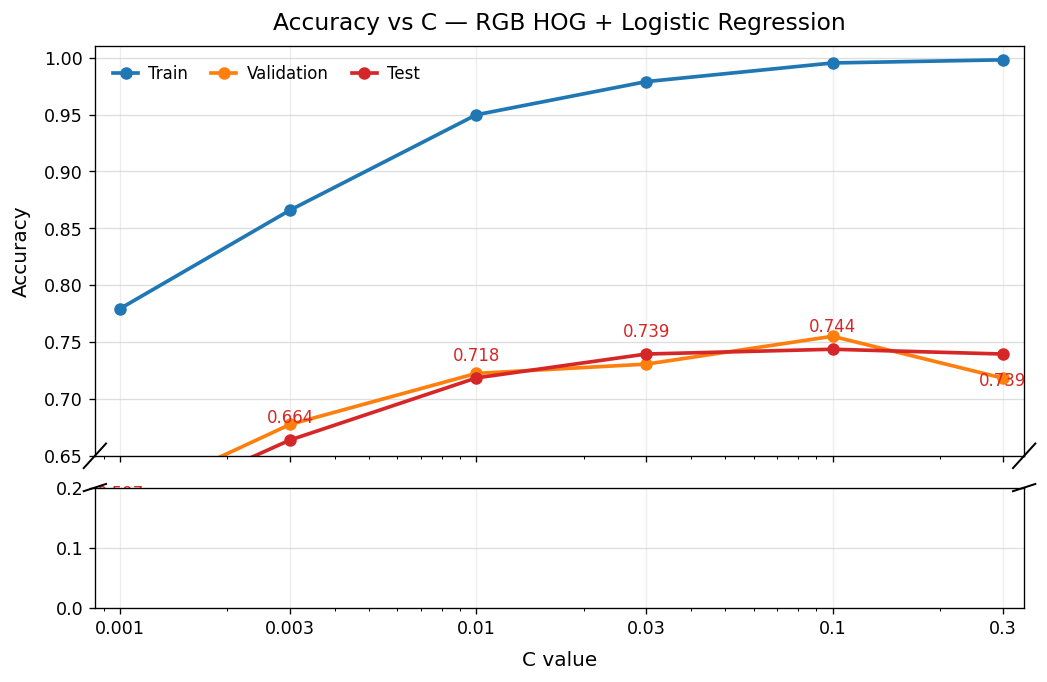

In [12]:
# We plot train, validation, and test accuracy across C values for the selected Logistic Regression feature setting
# using a clean broken y-axis with two solid rectangular panels.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from src.models.logisticRegressionModel import buildHogParamDict, buildSubsetFeatures

selectedImageSize = int(bestConfig["imageSize"])
selectedPixelsPerCell = (
    int(bestConfig["pixelsPerCell"][0]),
    int(bestConfig["pixelsPerCell"][1]),
)
selectedOrientations = int(bestConfig["orientations"])
selectedColorMode = str(bestConfig["colorMode"])

tuningSummaryDf = pd.read_csv(baselineSavedPathDict["tuningSummaryPath"])

selectedTrialRowsDf = tuningSummaryDf.loc[
    (
        (tuningSummaryDf["imageSize"] == selectedImageSize)
        & (tuningSummaryDf["pixelsPerCellX"] == selectedPixelsPerCell[0])
        & (tuningSummaryDf["pixelsPerCellY"] == selectedPixelsPerCell[1])
        & (tuningSummaryDf["orientations"] == selectedOrientations)
        & (tuningSummaryDf["colorMode"] == selectedColorMode)
    )
].copy()

selectedTrialRowsDf = selectedTrialRowsDf.sort_values("cValue").reset_index(drop=True)
cValueList = selectedTrialRowsDf["cValue"].astype(float).tolist()

strictManifestPath = projectConfig.manifestsDir / "modelingManifestStrict.csv"
strictManifestDf = pd.read_csv(strictManifestPath)

classToIndexMap = {
    className: classIndex
    for classIndex, className in enumerate(projectConfig.classNames)
}
indexToClassMap = {
    classIndex: className
    for classIndex, className in enumerate(projectConfig.classNames)
}

selectedHogParams = buildHogParamDict(
    orientations=selectedOrientations,
    pixelsPerCell=selectedPixelsPerCell,
)

trainFeatures, trainTargets, trainDf = buildSubsetFeatures(
    modelingManifestDf=strictManifestDf,
    subsetName="train",
    classToIndexMap=classToIndexMap,
    imageSize=selectedImageSize,
    hogParams=selectedHogParams,
    colorMode=selectedColorMode,
)

testFeatures, testTargets, testDf = buildSubsetFeatures(
    modelingManifestDf=strictManifestDf,
    subsetName="test",
    classToIndexMap=classToIndexMap,
    imageSize=selectedImageSize,
    hogParams=selectedHogParams,
    colorMode=selectedColorMode,
)

testAccuracyValueList = []

for cValue in cValueList:
    modelPipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    C=float(cValue),
                    class_weight="balanced",
                    solver="lbfgs",
                    random_state=projectConfig.seed,
                    max_iter=5000,
                    tol=1e-3,
                ),
            ),
        ]
    )

    modelPipeline.fit(trainFeatures, trainTargets)
    testPredictedIndices = modelPipeline.predict(testFeatures)

    testPredictedClassNames = [
        indexToClassMap[int(classIndex)]
        for classIndex in testPredictedIndices.tolist()
    ]

    testAccuracyValue = accuracy_score(
        testDf["className"],
        testPredictedClassNames,
    )

    testAccuracyValueList.append(float(testAccuracyValue))

plotDf = pd.DataFrame(
    {
        "cValue": cValueList,
        "trainAccuracy": selectedTrialRowsDf["trainAccuracy"].astype(float).tolist(),
        "valAccuracy": selectedTrialRowsDf["valAccuracy"].astype(float).tolist(),
        "testAccuracy": testAccuracyValueList,
    }
).sort_values("cValue").reset_index(drop=True)

xValues = plotDf["cValue"].astype(float).to_numpy()
trainValues = plotDf["trainAccuracy"].astype(float).to_numpy()
valValues = plotDf["valAccuracy"].astype(float).to_numpy()
testValues = plotDf["testAccuracy"].astype(float).to_numpy()

blueColor = "#1f77b4"
orangeColor = "#ff7f0e"
redColor = "#d62728"
gridColor = "#d0d0d0"

fig, (axTop, axBottom) = plt.subplots(
    2,
    1,
    figsize=(8.8, 6.0),
    sharex=True,
    gridspec_kw={"height_ratios": [3.4, 1.0], "hspace": 0.12},
)

for axisObject in [axTop, axBottom]:
    axisObject.plot(xValues, trainValues, marker="o", linewidth=2.2, markersize=6.5, color=blueColor, label="Train")
    axisObject.plot(xValues, valValues, marker="o", linewidth=2.2, markersize=6.5, color=orangeColor, label="Validation")
    axisObject.plot(xValues, testValues, marker="o", linewidth=2.2, markersize=6.5, color=redColor, label="Test")

    axisObject.grid(axis="y", color=gridColor, linewidth=0.8, alpha=0.7)
    axisObject.spines["top"].set_visible(True)
    axisObject.spines["right"].set_visible(True)
    axisObject.spines["left"].set_visible(True)
    axisObject.spines["bottom"].set_visible(True)

axTop.set_ylim(0.65, 1.01)
axBottom.set_ylim(0.00, 0.20)

axBottom.set_xscale("log")
axBottom.set_xlim(xValues.min() * 0.85, xValues.max() * 1.15)
axBottom.set_xticks(xValues)
axBottom.set_xticklabels([f"{currentValue:g}" for currentValue in xValues])

axTop.set_yticks(np.arange(0.65, 1.01, 0.05))
axBottom.set_yticks([0.0, 0.1, 0.2])

axTop.tick_params(axis="x", which="both", labelbottom=False)

breakKwargs = dict(color="black", clip_on=False, linewidth=1.2)
axTop.plot((-0.012, +0.012), (-0.03, +0.03), transform=axTop.transAxes, **breakKwargs)
axTop.plot((0.988, 1.012), (-0.03, +0.03), transform=axTop.transAxes, **breakKwargs)
axBottom.plot((-0.012, +0.012), (0.97, 1.03), transform=axBottom.transAxes, **breakKwargs)
axBottom.plot((0.988, 1.012), (0.97, 1.03), transform=axBottom.transAxes, **breakKwargs)

axTop.legend(
    loc="upper left",
    frameon=False,
    ncol=3,
    handlelength=1.5,
    columnspacing=1.4,
)

testYOffsetList = [0.012, 0.012, 0.012, 0.012, 0.012, -0.016]
for xValue, yValue, yOffset in zip(xValues, testValues, testYOffsetList):
    axTop.text(
        xValue,
        yValue + yOffset,
        f"{yValue:.3f}",
        ha="center",
        va="bottom" if yOffset >= 0 else "top",
        fontsize=10,
        color=redColor,
    )

axTop.set_title("Accuracy vs C — RGB HOG + Logistic Regression", pad=10)
axTop.set_ylabel("Accuracy")
axBottom.set_xlabel("C value")

fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.12)
plt.show()

In [13]:
# We save the approved Logistic Regression accuracy-versus-C figure.

from src.utils import saveFigure

logisticAccuracyCurvePath = saveFigure(
    fig=fig,
    outputDir=projectConfig.figuresDir / "logisticRegression",
    figureFileName="logistic_accuracy_vs_c_broken_axis_clean.png",
    closeFigure=False,
)

print("Saved figure:", logisticAccuracyCurvePath)

Saved figure: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/figures/logisticRegression/logistic_accuracy_vs_c_broken_axis_clean.png


### Interpretation

This plot shows how accuracy changes across the tested `C` values for the selected RGB HOG feature setting in Logistic Regression.

The upper panel focuses on the main score range, while the lower panel preserves the full scale from 0 to 0.2 so that the axis break remains explicit and visually honest. As `C` increases, the training accuracy rises steadily, which means weaker regularization allows the model to fit the training data more strongly. The validation and test curves also improve at first, but they do not keep improving indefinitely.

The validation curve is the most important one for selecting the final model. Here, validation accuracy reaches its strongest region around `C = 0.1`. The test curve follows a very similar shape and also remains strongest in the same region, which supports that this configuration generalizes well rather than performing well only on the validation split. At the same time, the persistent gap between the training curve and the validation/test curves shows that stronger training fit alone is not enough and must be balanced against generalization.

Overall, this figure supports the selected tuned RGB HOG + Logistic Regression baseline and shows that the chosen regularization level lies in a stable and meaningful part of the search space.